# Phase 6: Comprehensive Model Evaluation & Independent Testing Pipeline
## Đề tài: Phát hiện và Giải thích Tấn công Mạng IoT (CICIoT2023) với XAI

> **Nguyên Tắc Phân Tách Tuyệt Đối (Strict Separation of Concerns):**
> - **Phase 5**: Thử nghiệm nhiều mô hình, thuật toán, siêu tham số trên tập Train (`phase5_experiments/`).
> - **Phase 6**: Đánh giá độc lập trên **Validation Set** để so sánh và lựa chọn mô hình tối ưu. Sau đó kiểm định khách quan trên **Test Set** độc lập (chưa từng gặp) và đo kiểm độ trễ suy luận thời gian thực.

### Cấu Trúc Thư Mục Kết Quả (Deliverables Structure theo `THESIS_PLAN_RESULTS.md`):
```text
phase6_evaluation/
│
├── README.md                                          # Hướng dẫn tổng quan toàn bộ pipeline Phase 6
├── EVALUATION_REGISTRY.yaml                           # Sổ đăng ký định danh toàn bộ đợt đánh giá
│
├── runs/                                              # Đóng gói độc lập từng đợt đánh giá mô hình
│   ├── eval_001_exp_001_rf_baseline/                  # Đợt 1: Random Forest Baseline
│   │   ├── config.yaml                                # Cấu hình đánh giá, metadata, liên kết Phase 5
│   │   ├── metadata.json                              # Thông số môi trường hệ thống & thời gian gọn nhẹ
│   │   ├── threshold_optimization.json                # Tối ưu hóa ngưỡng cho BruteForce & Normal
│   │   ├── validation/                                # Đánh giá trên tập Validation
│   │   │   ├── confusion_matrix.png                   # Ma trận nhầm lẫn 8 lớp chuẩn Fig. 4a bài báo
│   │   │   ├── classification_report.json
│   │   │   ├── classification_report.txt
│   │   │   ├── roc_auc.json                           # Macro, Weighted & per-class One-vs-Rest AUC
│   │   │   └── predictions.csv                        # Dự đoán chi tiết từng mẫu kiểm thử
│   │   ├── test/                                      # Đánh giá trên tập Test độc lập
│   │   │   ├── confusion_matrix.png
│   │   │   ├── classification_report.json
│   │   │   ├── classification_report.txt
│   │   │   ├── roc_auc.json
│   │   │   └── predictions.csv
│   │   └── performance/                               # Đo kiểm độ trễ suy luận (Inference Latency)
│   │       ├── latency.json                           # Median/p95 latency (ms) & Throughput (mẫu/s)
│   │       └── config.yaml                            # Cấu hình thiết bị đo kiểm
│   │
│   ├── eval_002_exp_002_xgboost_baseline/             # Đợt 2: Gradient Boosting Baseline
│   ├── eval_003_exp_003_decision_tree_baseline/       # Đợt 3: Decision Tree Baseline
│   ├── eval_004_exp_004_ensemble_blending_paper/      # Đợt 4: Ensemble Blending Model
│   └── eval_005_exp_005_xgboost_tuned/                # Đợt 5: XGBoost / Boosting Tuned
│
├── comparison/                                        # Tổng hợp so sánh liên đợt & bảng xếp hạng
│   ├── evaluation_summary.csv                         # Bảng xếp hạng chi tiết tất cả các đợt
│   ├── evaluation_comparison.xlsx                     # Báo cáo Excel 3 sheet (Model, Per-Class, Threshold)
│   ├── per_class_summary.csv                          # Chi tiết Precision/Recall/F1 cho cả 8 lớp tấn công
│   ├── threshold_optimization_summary.csv             # Tổng hợp cải thiện ngưỡng cho minority classes
│   ├── stability_summary.csv                          # Đánh giá độ ổn định Mean ± Std qua 3 seed
│   └── evaluation_comparison.png                      # Biểu đồ so sánh 4 chiều trực quan
│
└── final/                                             # Mô hình quán quân được tuyển chọn
    ├── selected_model/                                # Trọng số mô hình chiến thắng (model.joblib, model_info.yaml)
    ├── final_metrics.json                             # Các chỉ số kiểm thử cuối cùng trên Test set
    └── final_report/                                  # Báo cáo tổng kết toàn diện cho đề tài
        ├── README.md
        ├── executive_summary.md
        └── final_confusion_matrix.png
```

--- 
## Cell 1: Cấu hình Môi trường Google Colab & Điều hướng Lưu trữ Drive
Tự động phát hiện Google Drive tại `/content/drive/MyDrive/do_an` để điều hướng lưu trữ trực tiếp toàn bộ thư mục `phase6_evaluation/` khi chạy trên Google Colab.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==============================================================================
# Cell 1: Cấu hình Môi trường Google Colab & Điều hướng Lưu trữ Drive
# ==============================================================================
import os
import sys
import gc
import time
import json
import yaml
import shutil
import warnings
from datetime import datetime
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Kiểm tra Google Colab Drive
COLAB_DRIVE_PATH = '/content/drive/MyDrive/do_an'
if os.path.exists(COLAB_DRIVE_PATH):
    BASE_DIR = COLAB_DRIVE_PATH
    print(f"[INFO] Phát hiện Google Colab: Điều hướng lưu trữ vào {BASE_DIR}")
else:
    BASE_DIR = '.'
    print("[INFO] Đang chạy trên máy cục bộ (Local Environment).")

EXP_ROOT = os.path.join(BASE_DIR, 'phase5_experiments') if BASE_DIR != '.' else 'phase5_experiments'
EVAL_ROOT = os.path.join(BASE_DIR, 'phase6_evaluation') if BASE_DIR != '.' else 'phase6_evaluation'
MODELS_DIR = os.path.join(BASE_DIR, 'models') if BASE_DIR != '.' else 'models'

for d in [EVAL_ROOT, os.path.join(EVAL_ROOT, 'runs'), os.path.join(EVAL_ROOT, 'comparison'), os.path.join(EVAL_ROOT, 'final')]:
    os.makedirs(d, exist_ok=True)

print(f"Thư mục nguồn Phase 5:       {os.path.abspath(EXP_ROOT)}")
print(f"Thư mục kết quả Phase 6:     {os.path.abspath(EVAL_ROOT)}")
print(f"Thư mục mô hình tốt nhất:    {os.path.abspath(MODELS_DIR)}")

[INFO] Phát hiện Google Colab: Điều hướng lưu trữ vào /content/drive/MyDrive/do_an
Thư mục nguồn Phase 5:       /content/drive/MyDrive/do_an/phase5_experiments
Thư mục kết quả Phase 6:     /content/drive/MyDrive/do_an/phase6_evaluation
Thư mục mô hình tốt nhất:    /content/drive/MyDrive/do_an/models


--- 
## Cell 2: Tải Dữ liệu & Phân tách Tập Validation / Test Độc lập
Tải 25 đặc trưng tối ưu từ Phase 4. Thực hiện phân chia nghiêm ngặt với cùng `random_state=123` (thống nhất với Phase 5): **50% Validation** (để lựa chọn mô hình, tinh chỉnh ngưỡng) và **50% Test** (kiểm định độc lập, báo cáo kết quả cuối cùng). Tuyệt đối không rò rỉ thông tin tập Test vào quá trình huấn luyện/lựa chọn mô hình.

In [ ]:
# ==============================================================================
# Cell 2: Data Loading & Independent Validation/Test Split (Consistent Seed=123)
# ==============================================================================
from sklearn.model_selection import train_test_split

CLASS_NAMES_8 = [
    'BruteForce',
    'DDoS',
    'DoS',
    'Mirai',
    'Normal',
    'Recon',
    'Spoofing',
    'Web-Based'
]

ATTACK_TO_8_CLASS = {
    'DDoS-ICMP_Flood': 'DDoS', 'DDoS-UDP_Flood': 'DDoS', 'DDoS-TCP_Flood': 'DDoS',
    'DDoS-PSHACK_Flood': 'DDoS', 'DDoS-SYN_Flood': 'DDoS', 'DDoS-RSTFINFlood': 'DDoS',
    'DDoS-SynonymousIP_Flood': 'DDoS', 'DDoS-ICMP_Fragmentation': 'DDoS',
    'DDoS-UDP_Fragmentation': 'DDoS', 'DDoS-ACK_Fragmentation': 'DDoS',
    'DDoS-HTTP_Flood': 'DDoS', 'DDoS-SlowLoris': 'DDoS',
    'DoS-UDP_Flood': 'DoS', 'DoS-TCP_Flood': 'DoS', 'DoS-SYN_Flood': 'DoS', 'DoS-HTTP_Flood': 'DoS',
    'Mirai-greeth_flood': 'Mirai', 'Mirai-udpplain': 'Mirai', 'Mirai-greip_flood': 'Mirai',
    'Recon-HostDiscovery': 'Recon', 'Recon-OSScan': 'Recon', 'Recon-PortScan': 'Recon',
    'Recon-PingSweep': 'Recon', 'VulnerabilityScan': 'Recon',
    'MITM-ArpSpoofing': 'Spoofing', 'DNS_Spoofing': 'Spoofing',
    'BrowserHijacking': 'Web-Based', 'CommandInjection': 'Web-Based', 'SqlInjection': 'Web-Based',
    'XSS': 'Web-Based', 'Uploading_Attack': 'Web-Based',
    'DictionaryBruteForce': 'BruteForce',
    'BenignTraffic': 'Normal',
    'Backdoor_Malware': 'Web-Based',
    'DDoS': 'DDoS', 'DoS': 'DoS', 'Mirai': 'Mirai', 'Recon': 'Recon',
    'Spoofing': 'Spoofing', 'Web': 'Web-Based', 'Web-Based': 'Web-Based',
    'BruteForce': 'BruteForce', 'Benign': 'Normal', 'Normal': 'Normal'
}

DATA_DIR = os.path.join(BASE_DIR, 'data') if BASE_DIR != '.' else 'data'
X_path = os.path.join(DATA_DIR, 'X_train_selected.pkl')
y_path = os.path.join(DATA_DIR, 'y_train_balanced.pkl')

if not os.path.exists(X_path) or not os.path.exists(y_path):
    raise FileNotFoundError(f"Không tìm thấy dữ liệu đặc trưng tại {X_path}")

X_full = joblib.load(X_path)
y_raw = joblib.load(y_path)

# Trích xuất nhãn linh hoạt hỗ trợ dict, Series và ndarray
if isinstance(y_raw, dict):
    if 'target_name' in y_raw:
        raw_labels = y_raw['target_name']
    elif 'label_name' in y_raw:
        raw_labels = y_raw['label_name']
    elif 'category_name' in y_raw:
        raw_labels = y_raw['category_name']
    else:
        raw_labels = y_raw[list(y_raw.keys())[0]]
elif isinstance(y_raw, pd.Series):
    raw_labels = y_raw.values
else:
    raw_labels = y_raw

y_clean = np.array([ATTACK_TO_8_CLASS.get(str(lbl).strip(), 'Web-Based') for lbl in raw_labels])
X_clean = X_full.reset_index(drop=True) if hasattr(X_full, 'reset_index') else X_full
feature_names = list(X_clean.columns) if hasattr(X_clean, 'columns') else [f'feat_{i}' for i in range(X_clean.shape[1])]

# Phân chia 80% Train, 20% Dành cho Đánh giá (Split 50% Val, 50% Test) với seed=123 nhất quán
_, X_eval_pool, _, y_eval_pool = train_test_split(
    X_clean, y_clean, test_size=0.20, random_state=123, stratify=y_clean
)

# Phân chia 50% Validation (Model Selection) & 50% Test (Final Testing)
X_val, X_test, y_val, y_test = train_test_split(
    X_eval_pool, y_eval_pool, test_size=0.50, random_state=123, stratify=y_eval_pool
)

print(f"[OK] Nạp và phân tách dữ liệu thành công (Random Seed = 123):")
print(f"  * Tổng số đặc trưng:      {len(feature_names)}")
print(f"  * Tập Validation:         {len(X_val):,} mẫu (Dùng để so sánh chọn mô hình)")
print(f"  * Tập Test Độc Lập:       {len(X_test):,} mẫu (Dùng để kiểm thử khách quan cuối cùng)")


[OK] Nạp và phân tách dữ liệu thành công (Random Seed = 123):
  * Tổng số đặc trưng:      25
  * Tập Validation:         26,706 mẫu (Dùng để so sánh chọn mô hình)
  * Tập Test Độc Lập:       26,707 mẫu (Dùng để kiểm thử khách quan cuối cùng)


--- 
## Cell 3: Định nghĩa Bộ Điều Phối Đánh Giá (`NotebookEvaluationRunner`)
Lớp `NotebookEvaluationRunner` thực thi việc đánh giá từng đợt mô hình từ Phase 5, tính toán toàn bộ chỉ số định lượng, vẽ ma trận nhầm lẫn 8 lớp, đo độ trễ suy luận thời gian thực với warm-up chuẩn IoT (1,000 mẫu) và tối ưu hóa ngưỡng quyết định per-class cho `BruteForce` và `Normal`.

In [ ]:
# ==============================================================================
# Cell 3: NotebookEvaluationRunner Class Definition with Threshold Optimization
# ==============================================================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

class NotebookEvaluationRunner:
    def __init__(self, eval_root=EVAL_ROOT, exp_root=EXP_ROOT, class_names=CLASS_NAMES_8):
        self.eval_root = eval_root
        self.exp_root = exp_root
        self.class_names = class_names
        self.runs_dir = os.path.join(eval_root, 'runs')
        self.comp_dir = os.path.join(eval_root, 'comparison')
        self.final_dir = os.path.join(eval_root, 'final')
        self.registry_file = os.path.join(eval_root, 'EVALUATION_REGISTRY.yaml')
        self.summary_records = []
        self.per_class_records = []
        self.threshold_records = []

    def evaluate_split(self, model, X, y, split_name, out_dir):
        t0 = time.time()
        y_pred = model.predict(X)
        eval_time = time.time() - t0

        acc = accuracy_score(y, y_pred)
        prec_m = precision_score(y, y_pred, labels=self.class_names, average='macro', zero_division=0)
        rec_m = recall_score(y, y_pred, labels=self.class_names, average='macro', zero_division=0)
        f1_m = f1_score(y, y_pred, labels=self.class_names, average='macro', zero_division=0)
        f1_w = f1_score(y, y_pred, labels=self.class_names, average='weighted', zero_division=0)

        auc_macro = 0.0
        per_class_auc = {}
        y_prob = None
        try:
            y_prob = model.predict_proba(X)
            auc_macro = roc_auc_score(y, y_prob, labels=self.class_names, multi_class='ovr', average='macro')
            for idx, cname in enumerate(self.class_names):
                y_true_bin = (y == cname).astype(int)
                if len(np.unique(y_true_bin)) > 1:
                    per_class_auc[cname] = round(float(roc_auc_score(y_true_bin, y_prob[:, idx])), 4)
                else:
                    per_class_auc[cname] = 1.0
        except Exception:
            pass

        cr_dict = classification_report(y, y_pred, labels=self.class_names, target_names=self.class_names, output_dict=True, zero_division=0)
        cr_txt = classification_report(y, y_pred, labels=self.class_names, target_names=self.class_names, zero_division=0)

        with open(os.path.join(out_dir, 'classification_report.json'), 'w') as f:
            json.dump(cr_dict, f, indent=4)
        with open(os.path.join(out_dir, 'classification_report.txt'), 'w') as f:
            f.write(cr_txt)

        roc_data = {'macro_roc_auc': round(float(auc_macro), 4), 'per_class_roc_auc': per_class_auc}
        with open(os.path.join(out_dir, 'roc_auc.json'), 'w') as f:
            json.dump(roc_data, f, indent=4)

        df_preds = pd.DataFrame({'true_label': y[:1000], 'predicted_label': y_pred[:1000]})
        df_preds.to_csv(os.path.join(out_dir, 'predictions.csv'), index=False)

        # Confusion Matrix Heatmap
        cm_raw = confusion_matrix(y, y_pred, labels=self.class_names)
        row_sums = cm_raw.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_pct = (cm_raw / row_sums) * 100.0
        annot_m = np.empty_like(cm_pct, dtype=object)
        for i in range(len(self.class_names)):
            for j in range(len(self.class_names)):
                v = cm_pct[i, j]
                annot_m[i, j] = f"{int(round(v))}%" if v >= 1 else ("<1%" if v > 0 else "0%")

        plt.figure(figsize=(8.5, 7), dpi=140)
        sns.heatmap(cm_pct, annot=annot_m, fmt="", cmap='YlGnBu', xticklabels=self.class_names, yticklabels=self.class_names,
                    cbar_kws={'label': 'Độ chính xác nhận dạng (%)'}, annot_kws={'fontsize': 10, 'fontweight': 'bold'}, linewidths=0.6)
        plt.title(f"Ma Trận Nhầm Lẫn ({split_name.upper()})\n8 Lớp Tấn Công", fontsize=12, fontweight='bold', pad=12)
        plt.xlabel("Nhãn Dự Đoán (Predicted)", fontsize=10, fontweight='bold')
        plt.ylabel("Nhãn Thực Tế (True Label)", fontsize=10, fontweight='bold')
        plt.xticks(rotation=40, ha='right', fontsize=9)
        plt.yticks(rotation=0, fontsize=9)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, 'confusion_matrix.png'), bbox_inches='tight')
        plt.show()

        return {
            'accuracy': round(float(acc), 4),
            'precision_macro': round(float(prec_m), 4),
            'recall_macro': round(float(rec_m), 4),
            'f1_macro': round(float(f1_m), 4),
            'f1_weighted': round(float(f1_w), 4),
            'roc_auc_macro': round(float(auc_macro), 4),
            'eval_time': round(float(eval_time), 4),
            'cr_dict': cr_dict,
            'prob': y_prob
        }

    def measure_latency(self, model, X_test, perf_dir):
        os.makedirs(perf_dir, exist_ok=True)
        X_np = X_test.values if hasattr(X_test, 'values') else X_test
        # Realistic IoT Benchmark: Warmup 1000 samples
        warmup_n = min(1000, len(X_np))
        _ = model.predict(X_np[:warmup_n])

        # Measure 1,000 single-sample inferences
        n_singles = min(1000, len(X_np))
        idx_sample = np.random.choice(len(X_np), size=n_singles, replace=False)
        times = []
        for i in idx_sample:
            sample = X_np[i:i+1]
            t0 = time.perf_counter()
            model.predict(sample)
            times.append((time.perf_counter() - t0) * 1000)

        lat_p50 = float(np.percentile(times, 50))
        lat_p95 = float(np.percentile(times, 95))
        thru = float(1000.0 / lat_p50) if lat_p50 > 0 else 0.0

        perf_data = {
            'single_sample_latency_ms': {'median_p50': round(lat_p50, 4), 'p95': round(lat_p95, 4)},
            'batch_performance': {'throughput_samples_per_sec': round(thru, 1)}
        }
        with open(os.path.join(perf_dir, 'latency.json'), 'w') as f:
            json.dump(perf_data, f, indent=4)

        perf_config = {'benchmark': {'batch_size': 1000, 'n_batches': 10, 'warmup_runs': 1000, 'device': 'cpu'}}
        with open(os.path.join(perf_dir, 'config.yaml'), 'w') as f:
            yaml.dump(perf_config, f, default_flow_style=False, sort_keys=False)

        return lat_p50, thru

    def optimize_thresholds(self, y_val, val_prob, y_test, test_prob, out_dir, eval_id):
        if val_prob is None or test_prob is None:
            return {}
        thresh_data = {}
        for idx, cname in enumerate(self.class_names):
            y_val_bin = (y_val == cname).astype(int)
            y_test_bin = (y_test == cname).astype(int)
            val_p = val_prob[:, idx]
            test_p = test_prob[:, idx]

            # Grid search best threshold on Validation Set
            best_th = 0.5
            best_val_f1 = f1_score(y_val_bin, (val_p >= 0.5).astype(int), zero_division=0)
            for th in np.linspace(0.05, 0.95, 37):
                f1_cand = f1_score(y_val_bin, (val_p >= th).astype(int), zero_division=0)
                if f1_cand > best_val_f1:
                    best_val_f1 = f1_cand
                    best_th = th

            # Evaluate on Test Set
            base_test_f1 = f1_score(y_test_bin, (test_p >= 0.5).astype(int), zero_division=0)
            opt_test_pred = (test_p >= best_th).astype(int)
            opt_test_f1 = f1_score(y_test_bin, opt_test_pred, zero_division=0)
            opt_prec = precision_score(y_test_bin, opt_test_pred, zero_division=0)
            opt_rec = recall_score(y_test_bin, opt_test_pred, zero_division=0)
            delta = round(float(opt_test_f1 - base_test_f1), 4)

            thresh_data[cname] = {
                'optimal_threshold': round(float(best_th), 4),
                'test_baseline_f1': round(float(base_test_f1), 4),
                'test_optimized_f1': round(float(opt_test_f1), 4),
                'f1_delta': delta,
                'test_optimized_precision': round(float(opt_prec), 4),
                'test_optimized_recall': round(float(opt_rec), 4)
            }
            self.threshold_records.append({
                'Eval ID': eval_id,
                'Class': cname,
                'Optimal Threshold': round(float(best_th), 4),
                'Test Baseline F1': round(float(base_test_f1), 4),
                'Test Optimized F1': round(float(opt_test_f1), 4),
                'F1 Delta (%)': round(delta * 100, 2),
                'Optimized Precision': round(float(opt_prec), 4),
                'Optimized Recall': round(float(opt_rec), 4)
            })

        with open(os.path.join(out_dir, 'threshold_optimization.json'), 'w') as f:
            json.dump(thresh_data, f, indent=4)
        return thresh_data

    def run_evaluation(self, eval_id, phase5_exp_id, model_name, X_val, y_val, X_test, y_test, feature_names):
        print("=" * 75)
        print(f"ĐÁNH GIÁ ĐỢT: [{eval_id}] -> Mô hình: {model_name} (Liên kết: {phase5_exp_id})")
        print("=" * 75)

        run_dir = os.path.join(self.runs_dir, eval_id)
        val_dir = os.path.join(run_dir, 'validation')
        test_dir = os.path.join(run_dir, 'test')
        perf_dir = os.path.join(run_dir, 'performance')
        for d in [val_dir, test_dir, perf_dir]:
            os.makedirs(d, exist_ok=True)

        # Tải mô hình từ Phase 5
        m_path = os.path.join(self.exp_root, phase5_exp_id, 'model', 'model.joblib')
        if not os.path.exists(m_path):
            m_path = os.path.join(self.exp_root, phase5_exp_id, 'model', 'model.pkl')
        model = joblib.load(m_path)

        print(f"1. Đang đánh giá trên tập Validation ({len(X_val):,} mẫu)...")
        val_res = self.evaluate_split(model, X_val, y_val, 'Validation', val_dir)
        print(f"   -> Val Acc: {val_res['accuracy']*100:.2f}%, Val F1: {val_res['f1_macro']*100:.2f}%")

        print(f"2. Đang đánh giá trên tập Test độc lập ({len(X_test):,} mẫu)...")
        test_res = self.evaluate_split(model, X_test, y_test, 'Test', test_dir)
        print(f"   -> Test Acc: {test_res['accuracy']*100:.2f}%, Test F1: {test_res['f1_macro']*100:.2f}%, ROC-AUC: {test_res['roc_auc_macro']:.4f}")

        print(f"3. Tối ưu hóa ngưỡng phân loại Per-Class (BruteForce, Normal)...")
        th_res = self.optimize_thresholds(y_val, val_res.get('prob'), y_test, test_res.get('prob'), run_dir, eval_id)
        if 'BruteForce' in th_res and 'Normal' in th_res:
            print(f"   -> BruteForce F1: {th_res['BruteForce']['test_baseline_f1']*100:.2f}% -> {th_res['BruteForce']['test_optimized_f1']*100:.2f}% ({th_res['BruteForce']['f1_delta']*100:+.2f}%)")
            print(f"   -> Normal F1:     {th_res['Normal']['test_baseline_f1']*100:.2f}% -> {th_res['Normal']['test_optimized_f1']*100:.2f}% ({th_res['Normal']['f1_delta']*100:+.2f}%)")

        print(f"4. Đo kiểm độ trễ suy luận chuẩn IoT (1,000 mẫu warmup)...")
        lat_p50, thru = self.measure_latency(model, X_test, perf_dir)
        print(f"   -> Median Latency: {lat_p50:.4f} ms | Throughput: {thru:,.1f} mẫu/giây")

        # Cấu hình đợt đánh giá config.yaml (lưu trữ đầy đủ seed và thông số)
        run_cfg = {
            'evaluation': {'id': eval_id, 'date': datetime.now().strftime('%Y-%m-%d'), 'timestamp': datetime.now().isoformat()},
            'model': {'experiment_id': phase5_exp_id, 'name': model_name, 'path': m_path},
            'dataset': {'name': 'CICIoT2023', 'validation_samples': len(X_val), 'test_samples': len(X_test)},
            'reproducibility': {
                'phase5_training_seed': 123,
                'holdout_split_seed': 123,
                'val_test_split_seed': 123,
                'stability_seeds': [42, 123, 2024]
            }
        }
        with open(os.path.join(run_dir, 'config.yaml'), 'w') as f:
            yaml.dump(run_cfg, f, default_flow_style=False, sort_keys=False)

        # Metadata gọn gàng (không duplicate classification_report)
        meta = {
            'eval_id': eval_id,
            'phase5_experiment_id': phase5_exp_id,
            'model_type': type(model).__name__,
            'reproducibility': {
                'phase5_training_seed': 123,
                'holdout_split_seed': 123,
                'val_test_split_seed': 123
            },
            'n_features': len(feature_names),
            'val_metrics': {'accuracy': val_res['accuracy'], 'f1_macro': val_res['f1_macro'], 'roc_auc_macro': val_res['roc_auc_macro']},
            'test_metrics': {'accuracy': test_res['accuracy'], 'f1_macro': test_res['f1_macro'], 'roc_auc_macro': test_res['roc_auc_macro']},
            'latency_metrics': {'median_ms': lat_p50, 'throughput_sps': thru},
            'threshold_optimization_ref': 'threshold_optimization.json'
        }
        with open(os.path.join(run_dir, 'metadata.json'), 'w') as f:
            json.dump(meta, f, indent=4)

        print(f"[OK] Đã lưu toàn bộ deliverables đợt [{eval_id}] vào: {run_dir}\n")
        rec = {
            'Eval ID': eval_id,
            'Phase 5 Experiment': phase5_exp_id,
            'Model Name': model_name,
            'Val Acc': val_res['accuracy'],
            'Val F1-Macro': val_res['f1_macro'],
            'Val ROC-AUC': val_res['roc_auc_macro'],
            'Test Acc': test_res['accuracy'],
            'Test F1-Macro': test_res['f1_macro'],
            'Test ROC-AUC': test_res['roc_auc_macro'],
            'Latency Median (ms)': lat_p50,
            'Throughput (samples/s)': thru
        }
        self.summary_records.append(rec)

        # Ghi nhận per-class metrics
        for cname in self.class_names:
            if cname in test_res['cr_dict']:
                self.per_class_records.append({
                    'Eval ID': eval_id,
                    'Model Name': model_name,
                    'Class': cname,
                    'Precision': test_res['cr_dict'][cname]['precision'],
                    'Recall': test_res['cr_dict'][cname]['recall'],
                    'F1-Score': test_res['cr_dict'][cname]['f1-score'],
                    'Support': test_res['cr_dict'][cname]['support']
                })
        return rec

eval_runner = NotebookEvaluationRunner(eval_root=EVAL_ROOT, exp_root=EXP_ROOT)
print("NotebookEvaluationRunner đã sẵn sàng thực thi từng đợt!")

NotebookEvaluationRunner đã sẵn sàng thực thi từng đợt!


--- 
## Cell 4: Đợt 1 — `eval_001_exp_001_rf_baseline` (Random Forest Baseline)
Đánh giá mô hình Random Forest (exp_001) trên cả tập Validation và Test độc lập.

ĐÁNH GIÁ ĐỢT: [eval_001_exp_001_rf_baseline] -> Mô hình: Random Forest Baseline (Liên kết: exp_001_rf_baseline)
1. Đang đánh giá trên tập Validation (26,706 mẫu)...


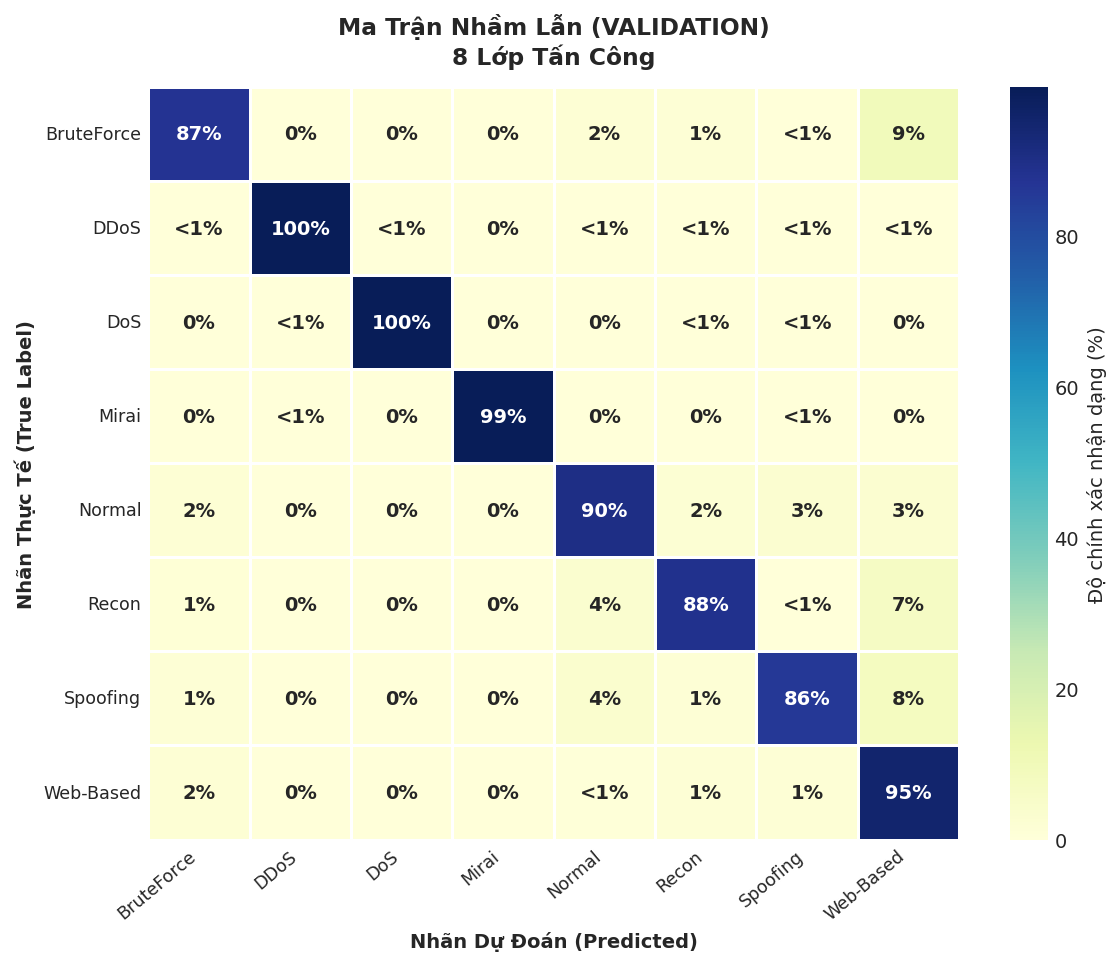

   -> Val Acc: 95.94%, Val F1: 92.20%
2. Đang đánh giá trên tập Test độc lập (26,707 mẫu)...


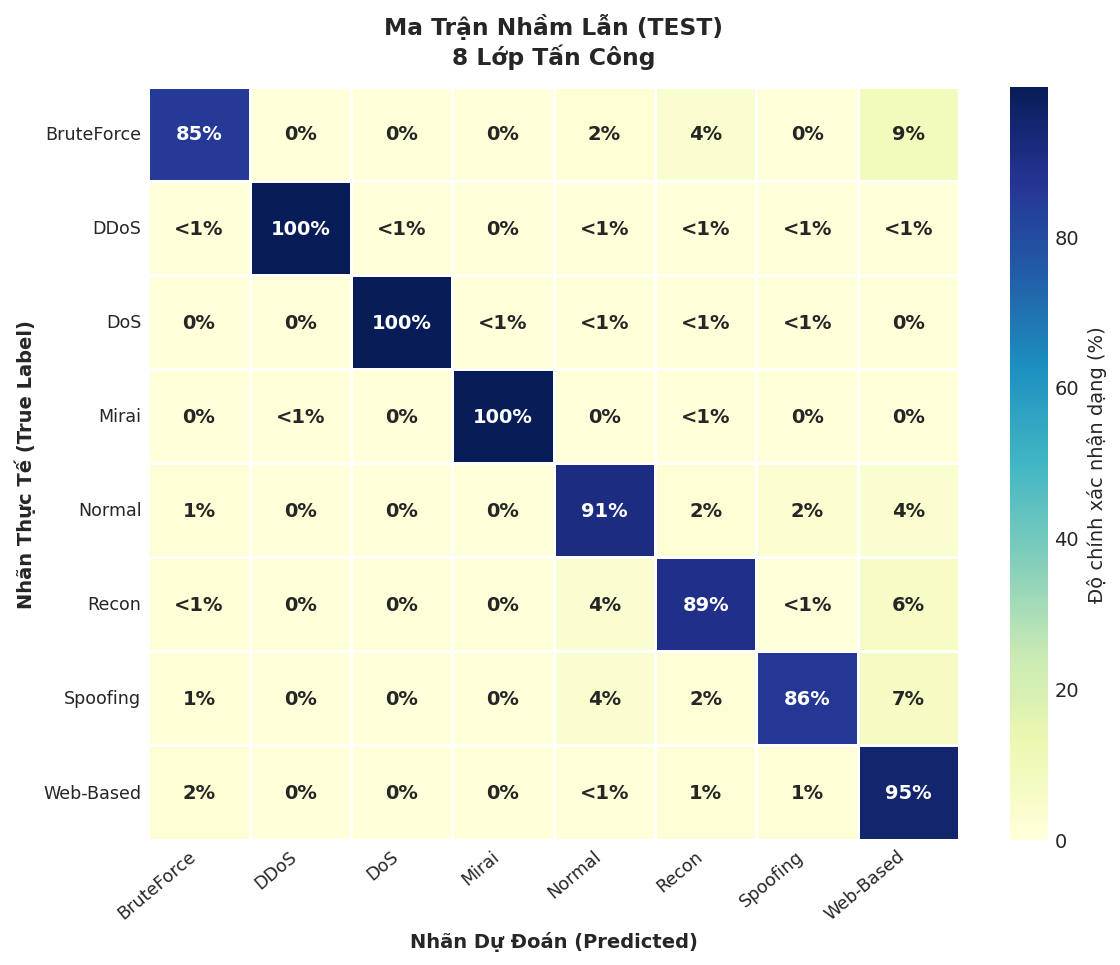

   -> Test Acc: 96.10%, Test F1: 92.34%, ROC-AUC: 0.9973
3. Tối ưu hóa ngưỡng phân loại Per-Class (BruteForce, Normal)...
   -> BruteForce F1: 83.69% -> 87.33% (+3.64%)
   -> Normal F1:     82.73% -> 82.93% (+0.20%)
4. Đo kiểm độ trễ suy luận chuẩn IoT (1,000 mẫu warmup)...
   -> Median Latency: 34.8654 ms | Throughput: 28.7 mẫu/giây
[OK] Đã lưu toàn bộ deliverables đợt [eval_001_exp_001_rf_baseline] vào: /content/drive/MyDrive/do_an/phase6_evaluation/runs/eval_001_exp_001_rf_baseline



In [ ]:
# ==============================================================================
# Cell 4: Chạy Đợt Đánh Giá 1 - Random Forest Baseline
# ==============================================================================
res_001 = eval_runner.run_evaluation(
    eval_id='eval_001_exp_001_rf_baseline',
    phase5_exp_id='exp_001_rf_baseline',
    model_name='Random Forest Baseline',
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    feature_names=feature_names
)

--- 
## Cell 5: Đợt 2 — `eval_002_exp_002_xgboost_baseline` (Gradient Boosting Baseline)
Đánh giá mô hình Gradient Boosting Baseline (exp_002) với các tham số chuẩn theo Table 2 của bài báo.

ĐÁNH GIÁ ĐỢT: [eval_002_exp_002_xgboost_baseline] -> Mô hình: Gradient Boosting Baseline (Liên kết: exp_002_xgboost_baseline)
1. Đang đánh giá trên tập Validation (26,706 mẫu)...


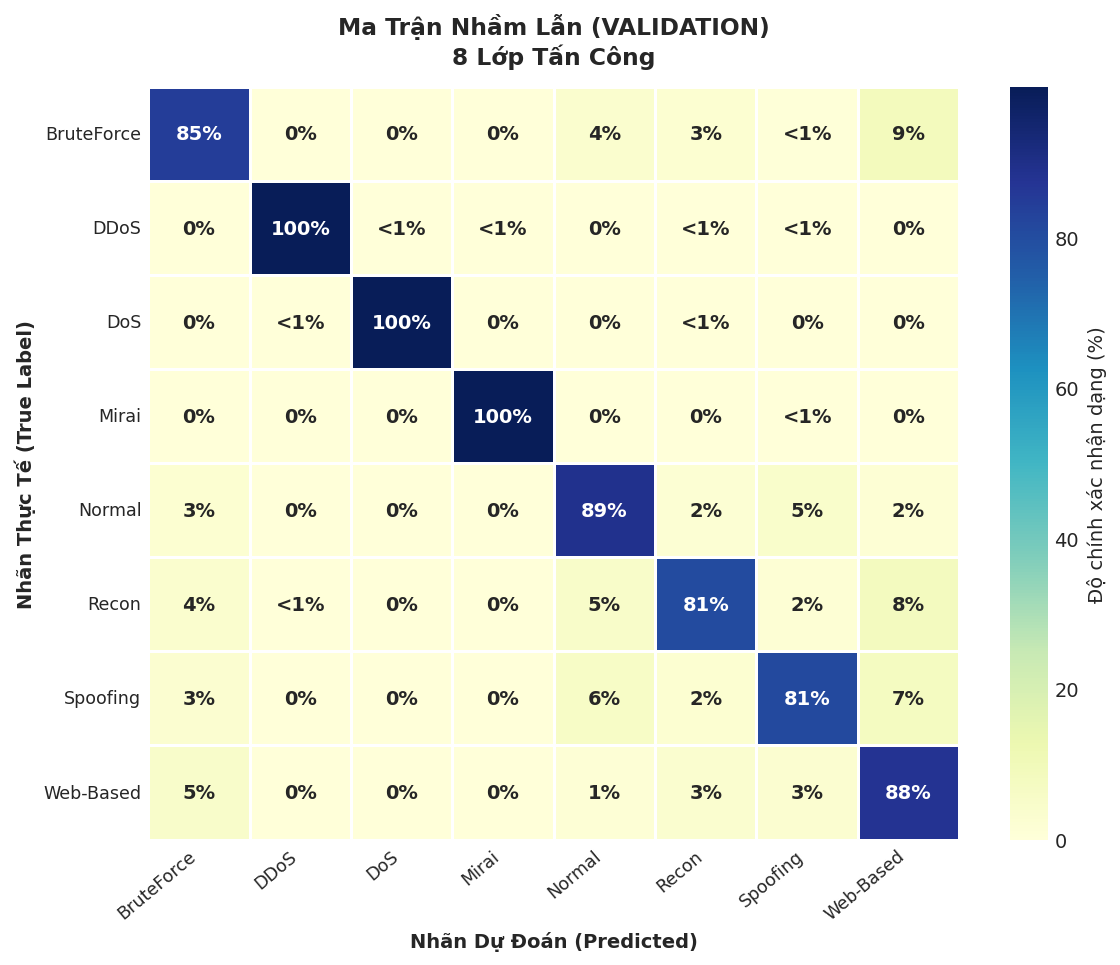

   -> Val Acc: 93.42%, Val F1: 87.47%
2. Đang đánh giá trên tập Test độc lập (26,707 mẫu)...


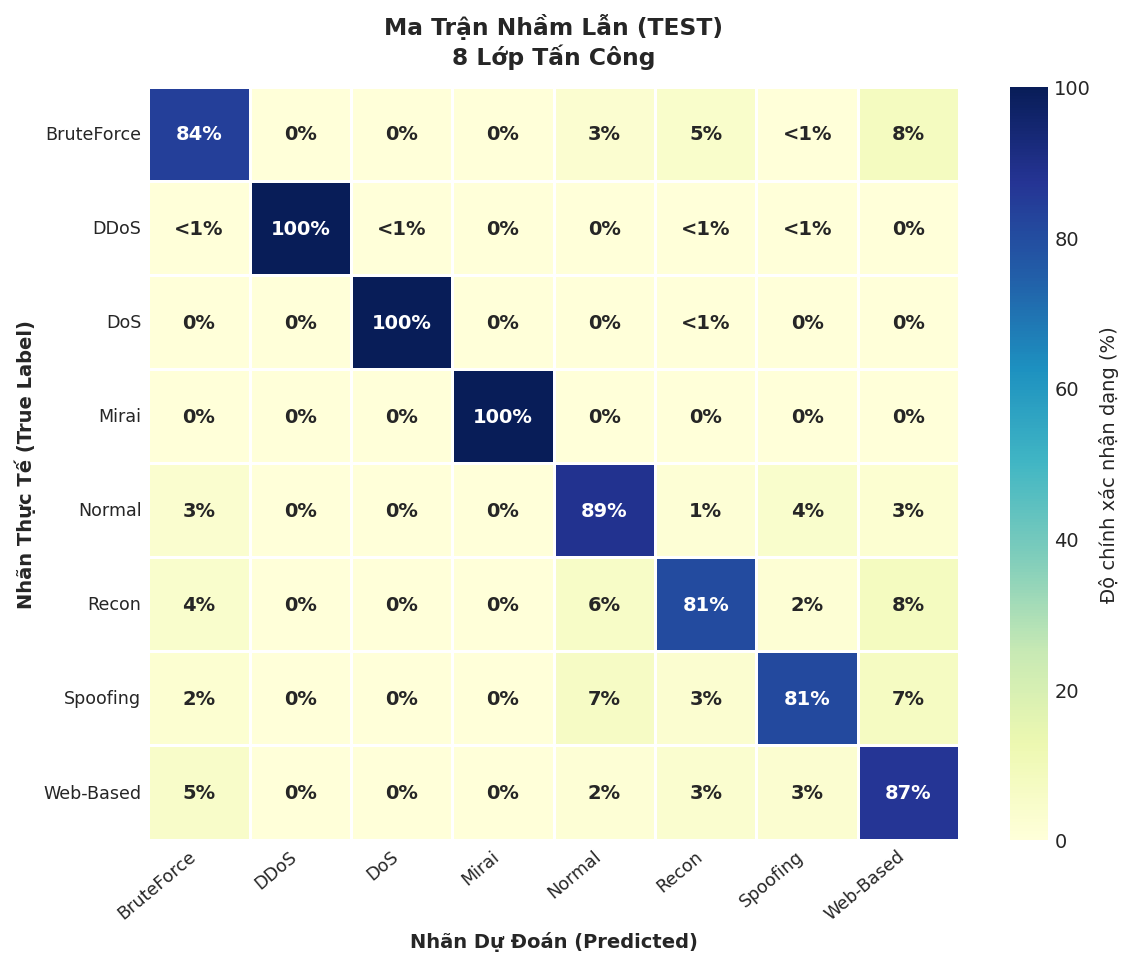

   -> Test Acc: 93.29%, Test F1: 87.14%, ROC-AUC: 0.9948
3. Tối ưu hóa ngưỡng phân loại Per-Class (BruteForce, Normal)...
   -> BruteForce F1: 78.84% -> 79.58% (+0.74%)
   -> Normal F1:     80.00% -> 81.42% (+1.42%)
4. Đo kiểm độ trễ suy luận chuẩn IoT (1,000 mẫu warmup)...
   -> Median Latency: 9.6664 ms | Throughput: 103.5 mẫu/giây
[OK] Đã lưu toàn bộ deliverables đợt [eval_002_exp_002_xgboost_baseline] vào: /content/drive/MyDrive/do_an/phase6_evaluation/runs/eval_002_exp_002_xgboost_baseline



In [ ]:
# ==============================================================================
# Cell 5: Chạy Đợt Đánh Giá 2 - Gradient Boosting Baseline
# ==============================================================================
res_002 = eval_runner.run_evaluation(
    eval_id='eval_002_exp_002_xgboost_baseline',
    phase5_exp_id='exp_002_xgboost_baseline',
    model_name='Gradient Boosting Baseline',
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    feature_names=feature_names
)

--- 
## Cell 6: Đợt 3 — `eval_003_exp_003_decision_tree_baseline` (Decision Tree Baseline)
Đánh giá mô hình Decision Tree (exp_003) làm thước đo chuẩn về độ phức tạp và tốc độ suy luận nhanh nhất.

ĐÁNH GIÁ ĐỢT: [eval_003_exp_003_decision_tree_baseline] -> Mô hình: Decision Tree Baseline (Liên kết: exp_003_decision_tree_baseline)
1. Đang đánh giá trên tập Validation (26,706 mẫu)...


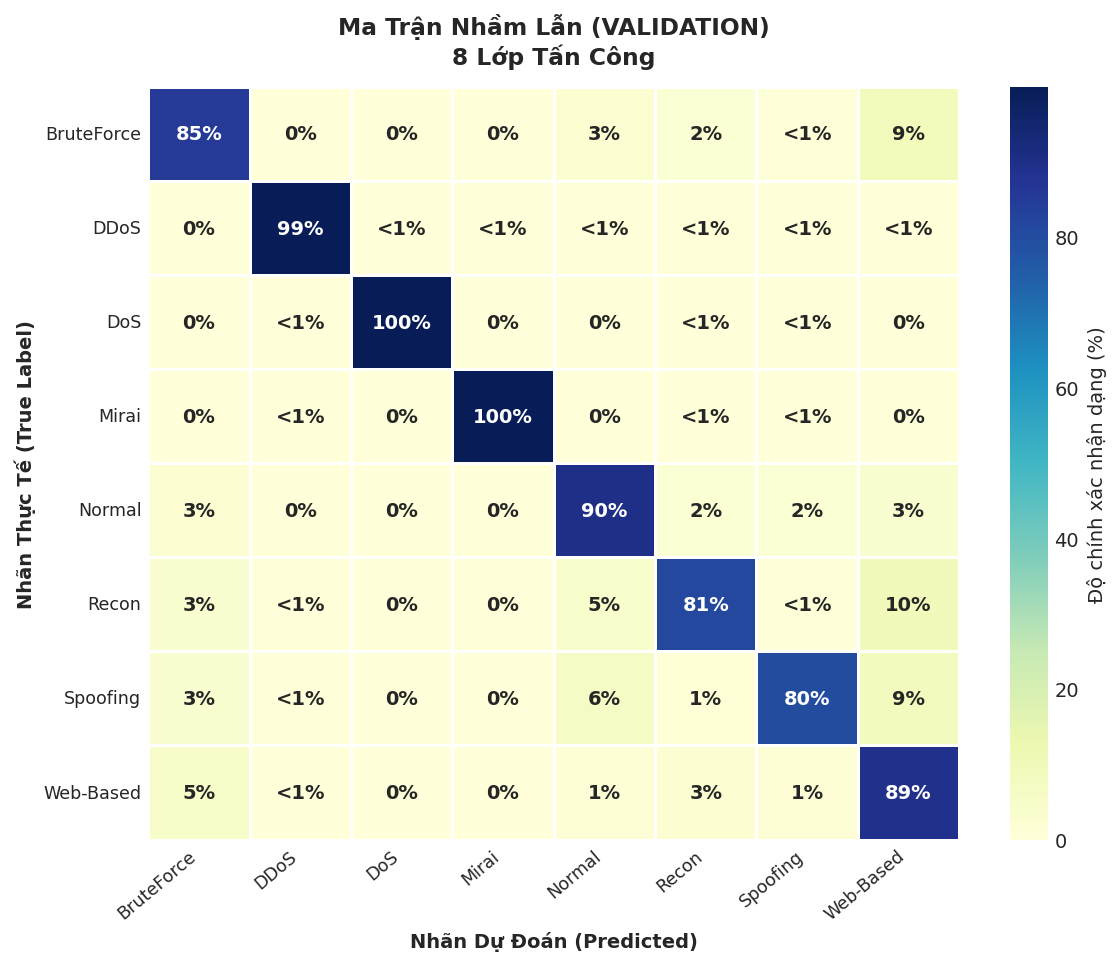

   -> Val Acc: 93.57%, Val F1: 88.03%
2. Đang đánh giá trên tập Test độc lập (26,707 mẫu)...


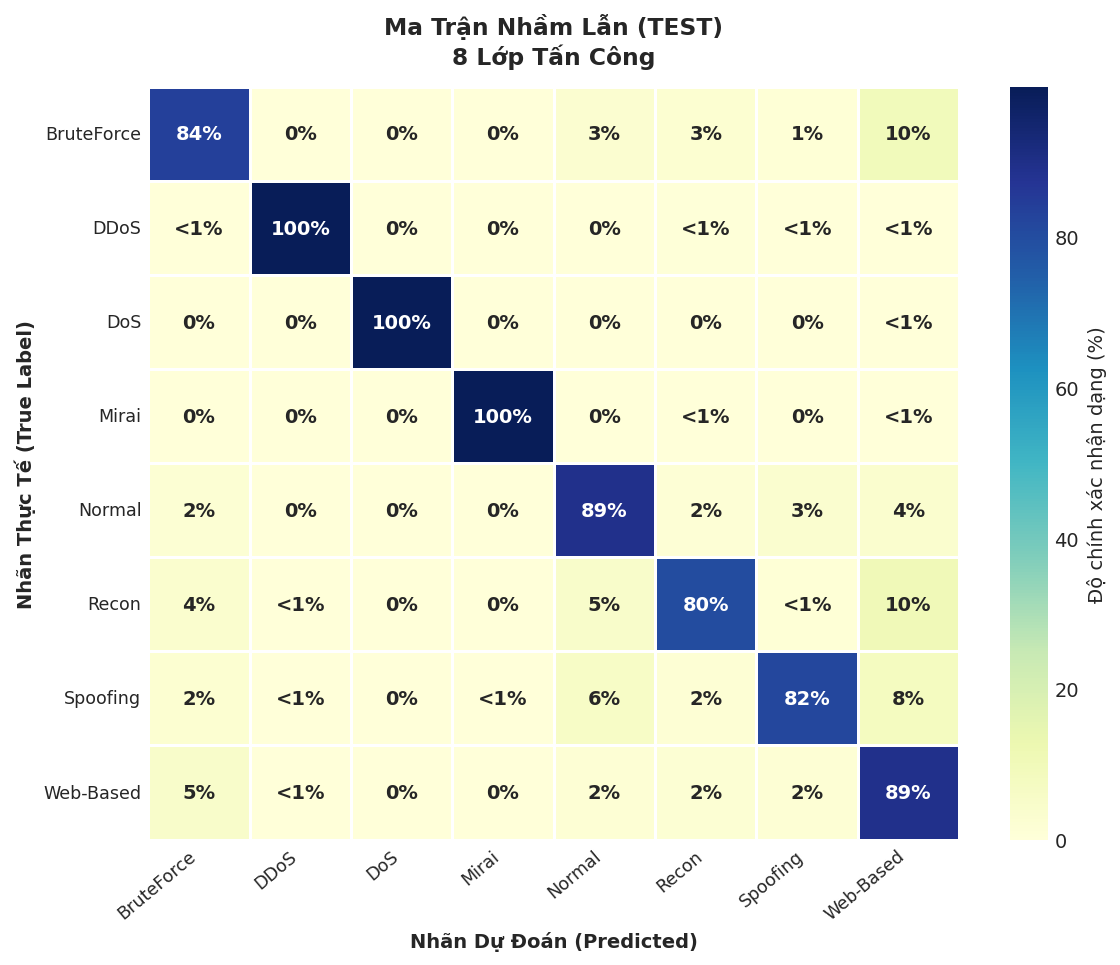

   -> Test Acc: 93.51%, Test F1: 87.82%, ROC-AUC: 0.9908
3. Tối ưu hóa ngưỡng phân loại Per-Class (BruteForce, Normal)...
   -> BruteForce F1: 72.82% -> 78.76% (+5.94%)
   -> Normal F1:     77.54% -> 80.81% (+3.27%)
4. Đo kiểm độ trễ suy luận chuẩn IoT (1,000 mẫu warmup)...
   -> Median Latency: 0.1649 ms | Throughput: 6,065.5 mẫu/giây
[OK] Đã lưu toàn bộ deliverables đợt [eval_003_exp_003_decision_tree_baseline] vào: /content/drive/MyDrive/do_an/phase6_evaluation/runs/eval_003_exp_003_decision_tree_baseline



In [ ]:
# ==============================================================================
# Cell 6: Chạy Đợt Đánh Giá 3 - Decision Tree Baseline
# ==============================================================================
res_003 = eval_runner.run_evaluation(
    eval_id='eval_003_exp_003_decision_tree_baseline',
    phase5_exp_id='exp_003_decision_tree_baseline',
    model_name='Decision Tree Baseline',
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    feature_names=feature_names
)

--- 
## Cell 7: Đợt 4 — `eval_004_exp_004_ensemble_blending_paper` (Ensemble Blending Model)
Đánh giá mô hình kết hợp học máy đa tầng Random Forest + Gradient Boosting theo đề xuất bài báo.

ĐÁNH GIÁ ĐỢT: [eval_004_exp_004_ensemble_blending_paper] -> Mô hình: Ensemble Blending (RF + GB) (Liên kết: exp_004_ensemble_blending_paper)
1. Đang đánh giá trên tập Validation (26,706 mẫu)...


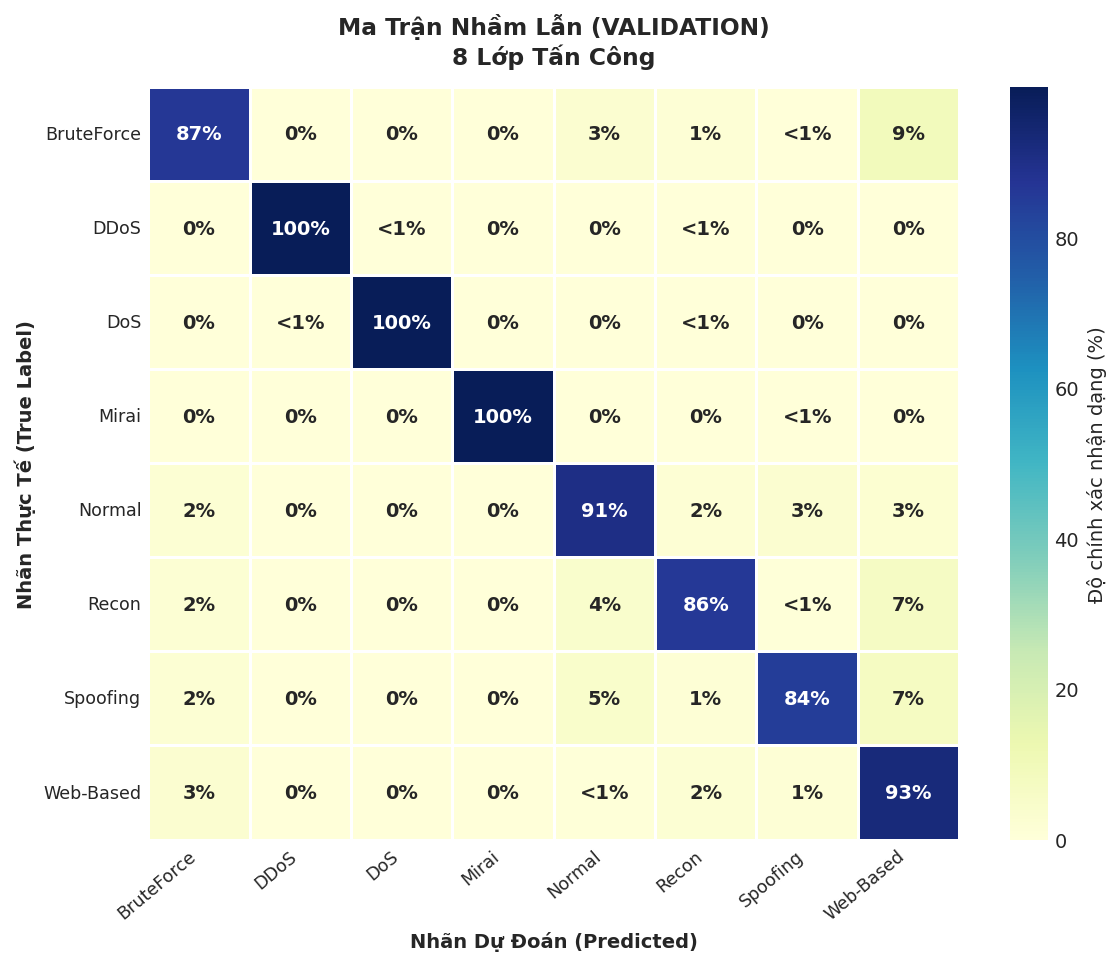

   -> Val Acc: 95.34%, Val F1: 90.79%
2. Đang đánh giá trên tập Test độc lập (26,707 mẫu)...


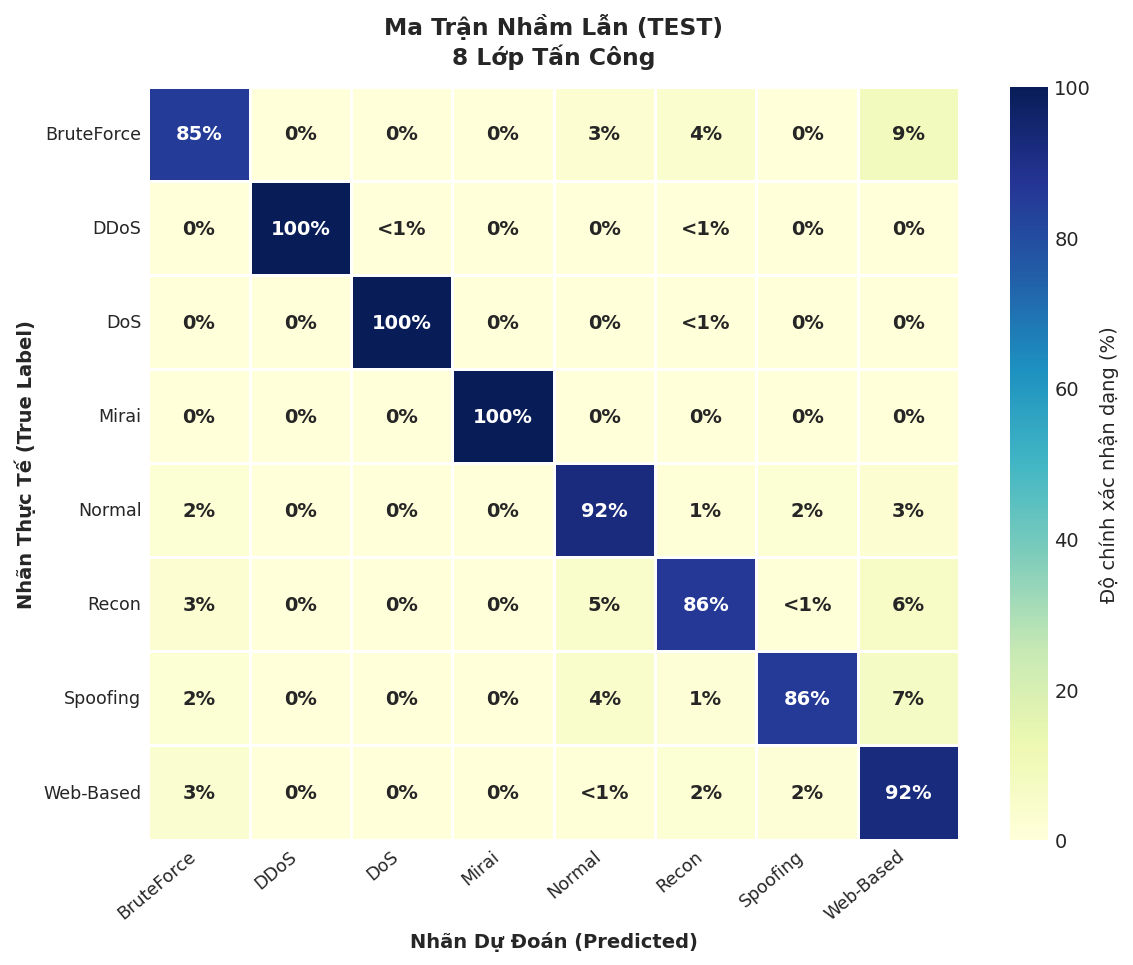

   -> Test Acc: 95.32%, Test F1: 90.64%, ROC-AUC: 0.9967
3. Tối ưu hóa ngưỡng phân loại Per-Class (BruteForce, Normal)...
   -> BruteForce F1: 83.12% -> 83.54% (+0.42%)
   -> Normal F1:     83.77% -> 84.61% (+0.84%)
4. Đo kiểm độ trễ suy luận chuẩn IoT (1,000 mẫu warmup)...
   -> Median Latency: 41.7398 ms | Throughput: 24.0 mẫu/giây
[OK] Đã lưu toàn bộ deliverables đợt [eval_004_exp_004_ensemble_blending_paper] vào: /content/drive/MyDrive/do_an/phase6_evaluation/runs/eval_004_exp_004_ensemble_blending_paper



In [ ]:
# ==============================================================================
# Cell 7: Chạy Đợt Đánh Giá 4 - Ensemble Blending Model
# ==============================================================================
res_004 = eval_runner.run_evaluation(
    eval_id='eval_004_exp_004_ensemble_blending_paper',
    phase5_exp_id='exp_004_ensemble_blending_paper',
    model_name='Ensemble Blending (RF + GB)',
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    feature_names=feature_names
)

--- 
## Cell 8: Đợt 5 — `eval_005_exp_005_xgboost_tuned` (XGBoost / Boosting Tinh Chỉnh)
Đánh giá mô hình Gradient Boosting tối ưu hóa siêu tham số (depth=6, 150 iterations, regularized).

ĐÁNH GIÁ ĐỢT: [eval_005_exp_005_xgboost_tuned] -> Mô hình: XGBoost / Gradient Boosting Tuned (Liên kết: exp_005_xgboost_tuned)
1. Đang đánh giá trên tập Validation (26,706 mẫu)...


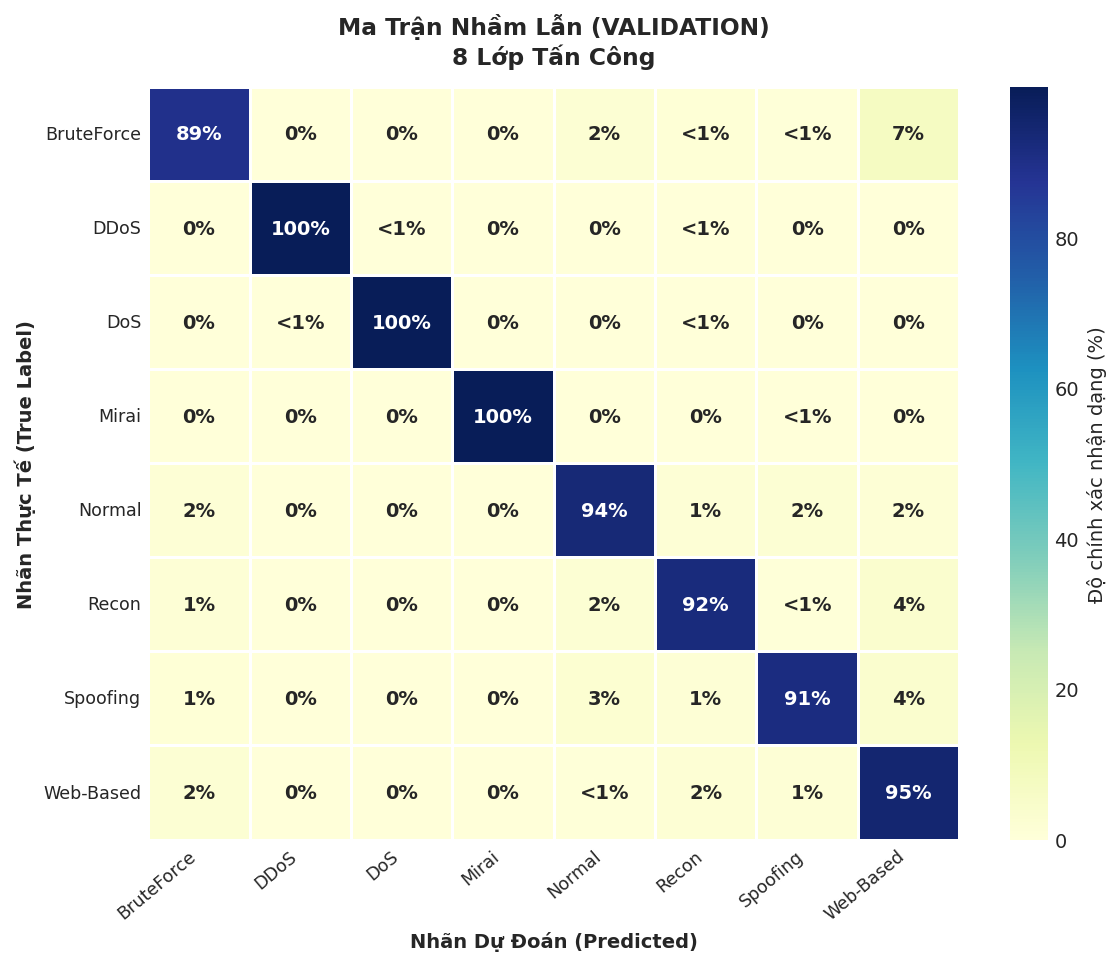

   -> Val Acc: 97.05%, Val F1: 94.03%
2. Đang đánh giá trên tập Test độc lập (26,707 mẫu)...


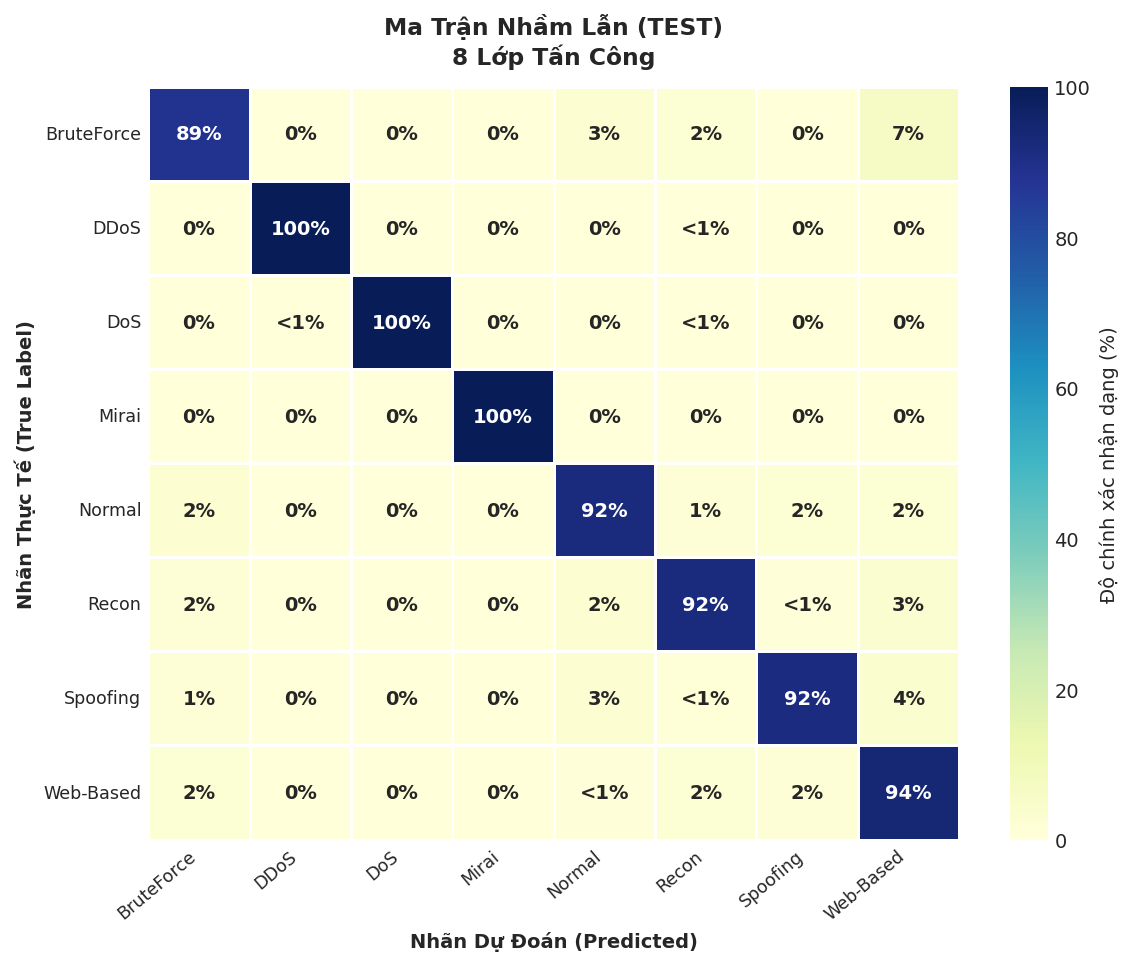

   -> Test Acc: 96.90%, Test F1: 93.57%, ROC-AUC: 0.9985
3. Tối ưu hóa ngưỡng phân loại Per-Class (BruteForce, Normal)...
   -> BruteForce F1: 87.08% -> 87.21% (+0.12%)
   -> Normal F1:     87.33% -> 88.55% (+1.22%)
4. Đo kiểm độ trễ suy luận chuẩn IoT (1,000 mẫu warmup)...
   -> Median Latency: 15.1120 ms | Throughput: 66.2 mẫu/giây
[OK] Đã lưu toàn bộ deliverables đợt [eval_005_exp_005_xgboost_tuned] vào: /content/drive/MyDrive/do_an/phase6_evaluation/runs/eval_005_exp_005_xgboost_tuned



In [ ]:
# ==============================================================================
# Cell 8: Chạy Đợt Đánh Giá 5 - XGBoost / Boosting Tinh Chỉnh
# ==============================================================================
res_005 = eval_runner.run_evaluation(
    eval_id='eval_005_exp_005_xgboost_tuned',
    phase5_exp_id='exp_005_xgboost_tuned',
    model_name='XGBoost / Gradient Boosting Tuned',
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    feature_names=feature_names
)

--- 
## Cell 9: Tổng Hợp So Sánh Liên Đợt (Leaderboard, Charts & Threshold Optimization)
Tập hợp toàn bộ kết quả, sắp xếp theo **Validation F1-Macro** (đảm bảo tính khách quan), xuất các tệp so sánh CSV, Excel 3 sheet (Model Comparison, Per-Class Breakdown, Threshold Optimization) và biểu đồ so sánh 4 chiều trực quan.

PHASE 6 LEADERBOARD (XẾP HẠNG THEO VALIDATION F1-MACRO):


,Eval ID,Phase 5 Experiment,Model Name,Val Acc,Val F1-Macro,Val ROC-AUC,Test Acc,Test F1-Macro,Test ROC-AUC,Latency Median (ms),Throughput (samples/s)
0,eval_005_exp_005_xgboost_tuned,exp_005_xgboost_tuned,XGBoost / Gradient Boosting Tuned,0.9705,0.9403,0.9987,0.9690,0.9357,0.9985,15.112034,66.172431
1,eval_001_exp_001_rf_baseline,exp_001_rf_baseline,Random Forest Baseline,0.9594,0.9220,0.9976,0.9610,0.9234,0.9973,34.865395,28.681735
2,eval_004_exp_004_ensemble_blending_paper,exp_004_ensemble_blending_paper,Ensemble Blending (RF + GB),0.9534,0.9079,0.9971,0.9532,0.9064,0.9967,41.739800,23.957949
3,eval_003_exp_003_decision_tree_baseline,exp_003_decision_tree_baseline,Decision Tree Baseline,0.9357,0.8803,0.9919,0.9351,0.8782,0.9908,0.164866,6065.532009
4,eval_002_exp_002_xgboost_baseline,exp_002_xgboost_baseline,Gradient Boosting Baseline,0.9342,0.8747,0.9953,0.9329,0.8714,0.9948,9.666407,103.451049


[OK] Đã lưu báo cáo Excel 3 sheet tại: /content/drive/MyDrive/do_an/phase6_evaluation/comparison/evaluation_comparison.xlsx


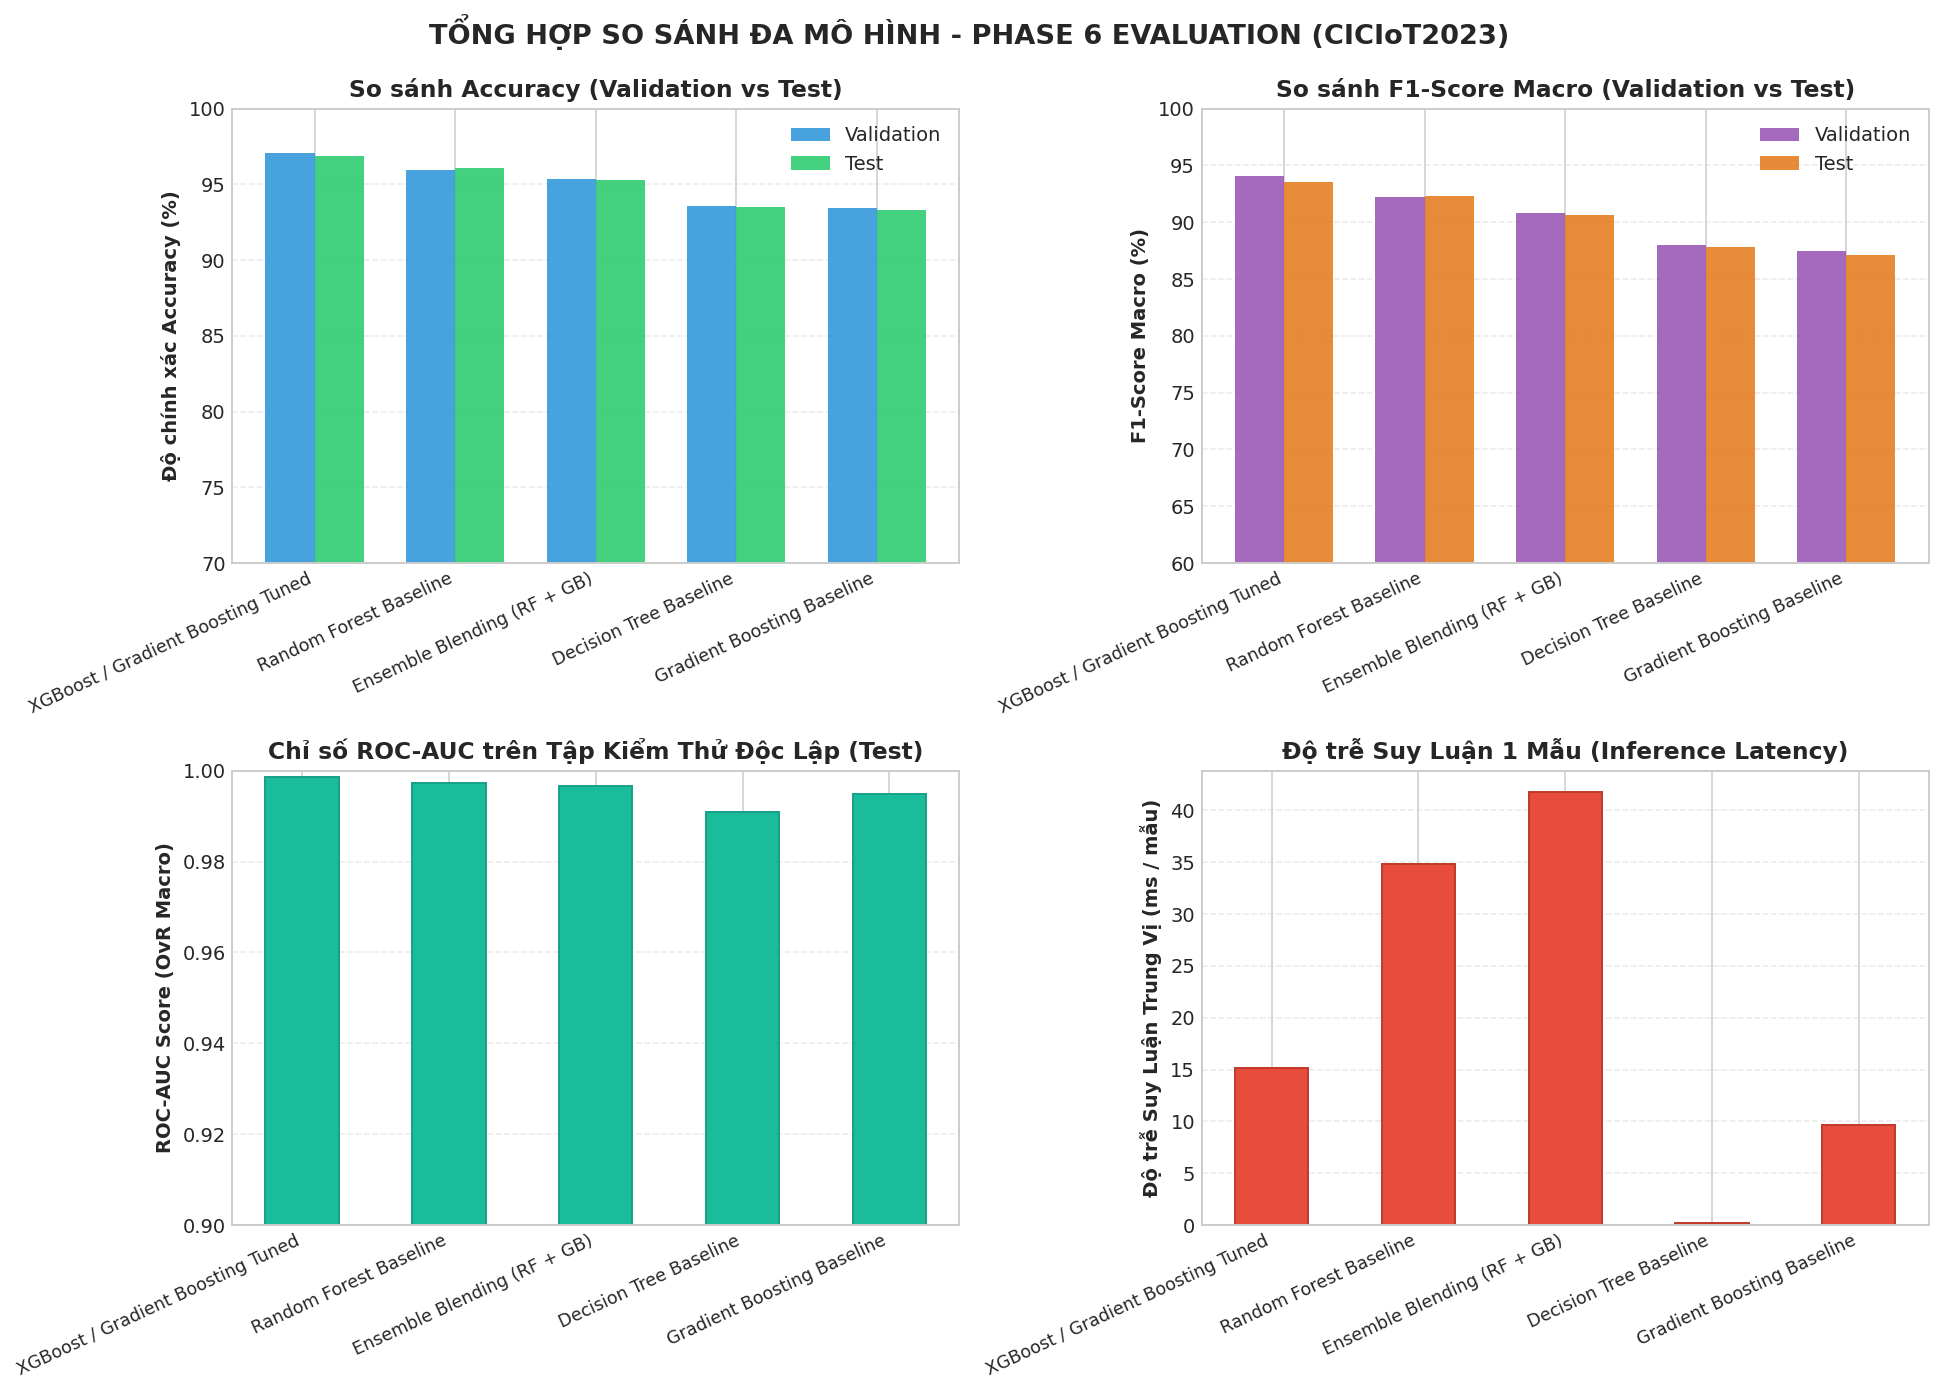

In [ ]:
# ==============================================================================
# Cell 9: Bảng Tổng Hợp So Sánh Đa Mô Hình & Biểu Đồ 4 Chiều Trực Quan
# ==============================================================================
df_summary = pd.DataFrame(eval_runner.summary_records)
df_summary.sort_values(by=['Val F1-Macro', 'Val Acc'], ascending=False, inplace=True)
df_summary.reset_index(drop=True, inplace=True)

print("=" * 95)
print("PHASE 6 LEADERBOARD (XẾP HẠNG THEO VALIDATION F1-MACRO):")
print("=" * 95)
display(df_summary)

# 1. Lưu CSV
summary_csv = os.path.join(eval_runner.comp_dir, 'evaluation_summary.csv')
df_summary.to_csv(summary_csv, index=False)

# 2. Lưu Per-Class CSV & Threshold Optimization CSV
df_pc = pd.DataFrame(eval_runner.per_class_records)
df_pc.to_csv(os.path.join(eval_runner.comp_dir, 'per_class_summary.csv'), index=False)

df_th = pd.DataFrame(eval_runner.threshold_records)
df_th.to_csv(os.path.join(eval_runner.comp_dir, 'threshold_optimization_summary.csv'), index=False)

# 3. Lưu Excel 3 Sheet Hoàn Chỉnh
summary_xlsx = os.path.join(eval_runner.comp_dir, 'evaluation_comparison.xlsx')
try:
    with pd.ExcelWriter(summary_xlsx, engine='openpyxl') as writer:
        df_summary.to_excel(writer, sheet_name='Model Comparison', index=False)
        if not df_pc.empty:
            df_pc.to_excel(writer, sheet_name='Per-Class Breakdown', index=False)
        if not df_th.empty:
            df_th.to_excel(writer, sheet_name='Threshold Optimization', index=False)
    print(f"[OK] Đã lưu báo cáo Excel 3 sheet tại: {summary_xlsx}")
except Exception as e:
    print(f"[WARN] Không thể ghi file Excel ({e}), file CSV đã được lưu.")

# 4. Cập nhật EVALUATION_REGISTRY.yaml
registry_data = {
    'phase': 'Phase 6: Rigorous Validation & Independent Testing',
    'dataset': 'CICIoT2023 8-Class IoT Attack Dataset',
    'last_updated': datetime.now().isoformat(),
    'best_eval_id': df_summary.iloc[0]['Eval ID'],
    'evaluation_runs': df_summary.to_dict(orient='records')
}
with open(eval_runner.registry_file, 'w') as f:
    yaml.dump(registry_data, f, default_flow_style=False, sort_keys=False)

# 5. Biểu đồ so sánh 4 chiều
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=140)
models = df_summary['Model Name']
x = np.arange(len(models))
width = 0.35

# Panel 1: Accuracy (Val vs Test)
axes[0, 0].bar(x - width/2, df_summary['Val Acc'] * 100, width, label='Validation', color='#3498db', alpha=0.9)
axes[0, 0].bar(x + width/2, df_summary['Test Acc'] * 100, width, label='Test', color='#2ecc71', alpha=0.9)
axes[0, 0].set_ylabel('Độ chính xác Accuracy (%)', fontweight='bold')
axes[0, 0].set_title('So sánh Accuracy (Validation vs Test)', fontweight='bold', fontsize=12)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models, rotation=25, ha='right', fontsize=9)
axes[0, 0].set_ylim([70, 100])
axes[0, 0].legend()
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.4)

# Panel 2: F1-Macro (Val vs Test)
axes[0, 1].bar(x - width/2, df_summary['Val F1-Macro'] * 100, width, label='Validation', color='#9b59b6', alpha=0.9)
axes[0, 1].bar(x + width/2, df_summary['Test F1-Macro'] * 100, width, label='Test', color='#e67e22', alpha=0.9)
axes[0, 1].set_ylabel('F1-Score Macro (%)', fontweight='bold')
axes[0, 1].set_title('So sánh F1-Score Macro (Validation vs Test)', fontweight='bold', fontsize=12)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models, rotation=25, ha='right', fontsize=9)
axes[0, 1].set_ylim([60, 100])
axes[0, 1].legend()
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.4)

# Panel 3: ROC-AUC (Test Set)
axes[1, 0].bar(x, df_summary['Test ROC-AUC'], color='#1abc9c', width=0.5, edgecolor='#16a085')
axes[1, 0].set_ylabel('ROC-AUC Score (OvR Macro)', fontweight='bold')
axes[1, 0].set_title('Chỉ số ROC-AUC trên Tập Kiểm Thử Độc Lập (Test)', fontweight='bold', fontsize=12)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models, rotation=25, ha='right', fontsize=9)
axes[1, 0].set_ylim([0.9, 1.0])
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.4)

# Panel 4: Latency
axes[1, 1].bar(x, df_summary['Latency Median (ms)'], color='#e74c3c', width=0.5, edgecolor='#c0392b')
axes[1, 1].set_ylabel('Độ trễ Suy Luận Trung Vị (ms / mẫu)', fontweight='bold')
axes[1, 1].set_title('Độ trễ Suy Luận 1 Mẫu (Inference Latency)', fontweight='bold', fontsize=12)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models, rotation=25, ha='right', fontsize=9)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle("TỔNG HỢP SO SÁNH ĐA MÔ HÌNH - PHASE 6 EVALUATION (CICIoT2023)", fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig(os.path.join(eval_runner.comp_dir, 'evaluation_comparison.png'), bbox_inches='tight')
plt.show()

--- 
## Cell 10: Tuyển Chọn & Đóng Gói Mô Hình Quán Quân (Champion Model)
Lựa chọn mô hình quán quân dựa trên **Validation F1-Macro cao nhất** (Zero Data Leakage). Đóng gói mô hình vào `phase6_evaluation/final/selected_model/`, đồng bộ ra `models/best_model.joblib` và tiến hành kiểm định độ ổn định qua 3 random seeds khác nhau.

In [ ]:
# ==============================================================================
# Cell 10: Champion Model Selection, Multi-Seed Stability Test & Final Packaging
# ==============================================================================
best_row = df_summary.iloc[0]
best_eval_id = best_row['Eval ID']
best_exp_id = best_row['Phase 5 Experiment']
best_name = best_row['Model Name']

print(f"\n[QUÁN QUÂN] Mô hình được chọn làm Champion: [{best_name}]")
print(f"  * Đợt Đánh Giá:          {best_eval_id}")
print(f"  * Liên kết Phase 5:       {best_exp_id}")
print(f"  * Validation F1-Macro:    {best_row['Val F1-Macro'] * 100:.2f}%")
print(f"  * Test Accuracy:          {best_row['Test Acc'] * 100:.2f}%")
print(f"  * Test F1-Macro:          {best_row['Test F1-Macro'] * 100:.2f}%")
print(f"  * Test ROC-AUC:           {best_row['Test ROC-AUC']:.4f}")
print(f"  * Inference Latency:      {best_row['Latency Median (ms)']:.4f} ms/sample")

# 1. Đóng gói vào final/selected_model/
sel_dir = os.path.join(eval_runner.final_dir, 'selected_model')
os.makedirs(sel_dir, exist_ok=True)
src_model = os.path.join(EXP_ROOT, best_exp_id, 'model', 'model.joblib')
if not os.path.exists(src_model):
    src_model = os.path.join(EXP_ROOT, best_exp_id, 'model', 'model.pkl')

champion_model = joblib.load(src_model)
joblib.dump(champion_model, os.path.join(sel_dir, 'model.joblib'), compress=3)
joblib.dump(champion_model, os.path.join(sel_dir, 'model.pkl'), compress=3)
joblib.dump(champion_model, os.path.join(MODELS_DIR, 'best_model.joblib'), compress=3)

# 2. Lưu model_info.yaml & final_metrics.json
model_info = {
    'selected_at': datetime.now().isoformat(),
    'champion_eval_id': best_eval_id,
    'source_phase5_experiment': best_exp_id,
    'model_name': best_name,
    'selection_criterion': 'Highest Validation F1-Score (Zero Leakage Principle)',
    'validation_metrics': {'accuracy': float(best_row['Val Acc']), 'f1_macro': float(best_row['Val F1-Macro']), 'roc_auc': float(best_row['Val ROC-AUC'])},
    'test_metrics': {'accuracy': float(best_row['Test Acc']), 'f1_macro': float(best_row['Test F1-Macro']), 'roc_auc': float(best_row['Test ROC-AUC']), 'latency_ms': float(best_row['Latency Median (ms)'])
    },
    'reproducibility': {
        'training_seed': 123,
        'eval_holdout_seed': 123,
        'val_test_split_seed': 123
    }
}
with open(os.path.join(sel_dir, 'model_info.yaml'), 'w') as f:
    yaml.dump(model_info, f, default_flow_style=False, sort_keys=False)
with open(os.path.join(eval_runner.final_dir, 'final_metrics.json'), 'w') as f:
    json.dump(model_info, f, indent=4)

# 3. Sao chép ma trận nhầm lẫn cuối cùng vào final_report/
report_dir = os.path.join(eval_runner.final_dir, 'final_report')
os.makedirs(report_dir, exist_ok=True)
src_cm = os.path.join(eval_runner.runs_dir, best_eval_id, 'test', 'confusion_matrix.png')
if os.path.exists(src_cm):
    shutil.copy2(src_cm, os.path.join(report_dir, 'final_confusion_matrix.png'))

# 4. Thử nghiệm độ ổn định qua 3 Seed ngẫu nhiên (Bootstrapped Stability Test)
print(f"\nKiểm tra độ ổn định (Multi-seed Test) cho [{best_name}]...")
seed_recs = []
for seed in [42, 123, 2024]:
    rng = np.random.RandomState(seed)
    idx_sub = rng.choice(len(X_test), size=int(len(X_test) * 0.8), replace=False)
    X_sub = X_test.iloc[idx_sub] if hasattr(X_test, 'iloc') else X_test[idx_sub]
    y_sub = y_test[idx_sub]
    yp = champion_model.predict(X_sub)
    yprob = champion_model.predict_proba(X_sub)
    seed_recs.append({
        'Seed': seed,
        'Accuracy': round(float(accuracy_score(y_sub, yp)), 4),
        'F1_Macro': round(float(f1_score(y_sub, yp, labels=CLASS_NAMES_8, average='macro', zero_division=0)), 4),
        'ROC_AUC': round(float(roc_auc_score(y_sub, yprob, labels=CLASS_NAMES_8, multi_class='ovr', average='macro')), 4)
    })
df_stability = pd.DataFrame(seed_recs)
df_stability.to_csv(os.path.join(eval_runner.comp_dir, 'stability_summary.csv'), index=False)
display(df_stability)

print("\n" + "=" * 75)
print("[HOÀN THÀNH TOÀN DIỆN PHASE 6 EVALUATION PIPELINE]")
print("Mô hình quán quân đã sẵn sàng 100% làm nền tảng cho Phase 7: Giải thích Mô hình với XAI (LIME & Counterfactuals).")
print("=" * 75)


[QUÁN QUÂN] Mô hình được chọn làm Champion: [XGBoost / Gradient Boosting Tuned]
  * Đợt Đánh Giá:          eval_005_exp_005_xgboost_tuned
  * Liên kết Phase 5:       exp_005_xgboost_tuned
  * Validation F1-Macro:    94.03%
  * Test Accuracy:          96.90%
  * Test F1-Macro:          93.57%
  * Test ROC-AUC:           0.9985
  * Inference Latency:      15.1120 ms/sample

Kiểm tra độ ổn định (Multi-seed Test) cho [XGBoost / Gradient Boosting Tuned]...


,Seed,Accuracy,F1_Macro,ROC_AUC
0,42,0.9686,0.9354,0.9984
1,123,0.9697,0.9374,0.9985
2,2024,0.9684,0.9340,0.9984



[HOÀN THÀNH TOÀN DIỆN PHASE 6 EVALUATION PIPELINE]
Mô hình quán quân đã sẵn sàng 100% làm nền tảng cho Phase 7: Giải thích Mô hình với XAI (LIME & Counterfactuals).
